In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer

# Loading the Data set
df = pd.read_csv("/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv")


In [2]:
# Check dataframe values
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


In [3]:
# Check Dataframe description like Data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
# Check count, mean, std
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
# Check duplicates
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9795    False
9796    False
9797    False
9798    False
9799    False
Length: 9800, dtype: bool

In [6]:
#Check missing data percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64


In [7]:
# Eliminate unnecessary columns
df.drop(['Order ID','Ship Date','Row ID','Ship Mode','Sub-Category','Postal Code','Customer Name','Customer ID','Product ID','Country'], axis=1, inplace=True)
# df.drop('Product Name', axis =1, inplace = True)

In [8]:
# Check Total Rows and columns
df.shape

(9800, 8)

In [9]:
# Check null value
df.isnull().sum()

Order Date      0
Segment         0
City            0
State           0
Region          0
Category        0
Product Name    0
Sales           0
dtype: int64

Convert Date

In [10]:
# Convert Date type into Data format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [11]:
# Checked daily sales to analyze data
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
print(daily_sales)

     Order Date      Sales
0    2015-01-03    16.4480
1    2015-01-04   288.0600
2    2015-01-05    19.5360
3    2015-01-06  4407.1000
4    2015-01-07    87.1580
...         ...        ...
1225 2018-12-26   814.5940
1226 2018-12-27   177.6360
1227 2018-12-28  1657.3508
1228 2018-12-29  2915.5340
1229 2018-12-30   713.7900

[1230 rows x 2 columns]


In [12]:
# Check in which date we gets maximum sales
max_sales_date_row = daily_sales.loc[daily_sales['Sales'].idxmax()]
print(max_sales_date_row)

Order Date    2015-03-18 00:00:00
Sales                   28106.716
Name: 53, dtype: object


In [13]:
# 4. Extract the date and sales amount
highest_sales_date = max_sales_date_row['Order Date']
print(highest_sales_date)
highest_sales_amount = max_sales_date_row['Sales']
print(highest_sales_amount)

2015-03-18 00:00:00
28106.716


In [14]:
# Analyze that in which month we gets maximum sales (for temp remove)
#df['month'] = df['Order Date'].dt.month
#df.groupby('month')['Sales'].sum().sort_values(ascending = False)

In [15]:
# Check Duplicates
df.duplicated().sum
df = df.drop_duplicates()

In [16]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9795    False
9796    False
9797    False
9798    False
9799    False
Length: 9799, dtype: bool

In [17]:
# Check for Hidden Missing Values
df.isnull().sum()

Order Date      0
Segment         0
City            0
State           0
Region          0
Category        0
Product Name    0
Sales           0
dtype: int64

In [18]:
# Remove unnessary spaces from the data
(df == '').sum()

Order Date      0
Segment         0
City            0
State           0
Region          0
Category        0
Product Name    0
Sales           0
dtype: int64

In [19]:
# Check Outliers
df['Sales'].describe()

count     9799.000000
mean       230.763895
std        626.683644
min          0.444000
25%         17.248000
50%         54.480000
75%        210.572000
max      22638.480000
Name: Sales, dtype: float64

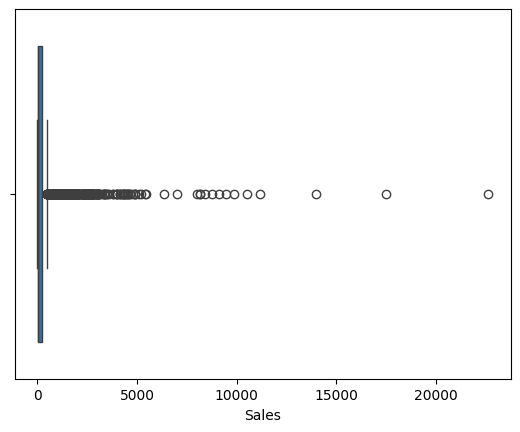

In [20]:
sns.boxplot(x=df['Sales'])
plt.show()

In [21]:
# Using IQR method to check outliers
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR 

outlier = df[(df['Sales']< lower) | (df['Sales'] > upper)]
print(outlier)

     Order Date    Segment             City       State   Region  \
1    2017-11-08   Consumer        Henderson    Kentucky    South   
3    2016-10-11   Consumer  Fort Lauderdale     Florida    South   
7    2015-06-09   Consumer      Los Angeles  California     West   
10   2015-06-09   Consumer      Los Angeles  California     West   
11   2015-06-09   Consumer      Los Angeles  California     West   
...         ...        ...              ...         ...      ...   
9759 2017-10-31  Corporate    San Francisco  California     West   
9774 2015-07-26   Consumer      San Antonio       Texas  Central   
9781 2017-09-14   Consumer       Long Beach    New York     East   
9787 2018-03-27   Consumer          Houston       Texas  Central   
9788 2018-03-27   Consumer          Houston       Texas  Central   

             Category                                       Product Name  \
1           Furniture  Hon Deluxe Fabric Upholstered Stacking Chairs,...   
3           Furniture      Bret

Using Z-Score (For Normal Distribution)
Works when data is normally distributed

In [22]:
from scipy import stats

z = stats.zscore(df['Sales'])

outliers = df[(z > 3) | (z < -3)]
print(outliers)


     Order Date      Segment           City           State   Region  \
27   2016-09-17     Consumer   Philadelphia    Pennsylvania     East   
165  2015-09-08     Consumer    San Antonio           Texas  Central   
251  2017-09-11     Consumer      San Diego      California     West   
262  2015-09-19    Corporate        Houston           Texas  Central   
263  2015-09-19    Corporate        Houston           Texas  Central   
...         ...          ...            ...             ...      ...   
9639 2016-01-28     Consumer        Concord  North Carolina    South   
9649 2017-11-26     Consumer    Los Angeles      California     West   
9660 2017-06-06  Home Office  Santa Barbara      California     West   
9741 2016-11-08    Corporate     Burlington         Vermont     East   
9774 2015-07-26     Consumer    San Antonio           Texas  Central   

             Category                                       Product Name  \
27          Furniture  Riverside Palais Royal Lawyers Bookc

In [23]:
# Remove Outliers (Simple way)
df_clean = df[(df['Sales']>= lower) & (df['Sales'] <= upper)]

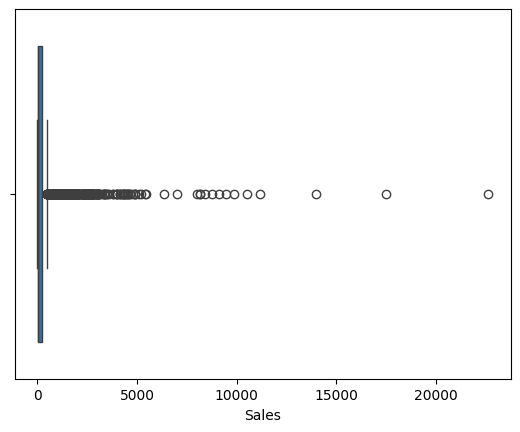

In [24]:
sns.boxplot(x=df['Sales'])
plt.show()

In [25]:
# Cap (Winsorization)
# Instead of deleting, we limit extreme values
df['Sales'] = df['Sales'].clip(lower, upper)

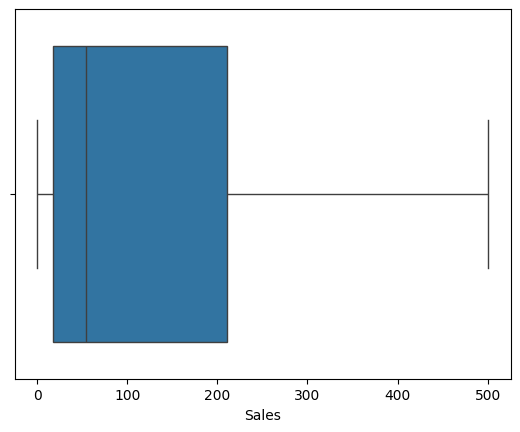

In [26]:
sns.boxplot(x=df['Sales'])
plt.show()

In [27]:
df['Sales'] = np.log(df['Sales'])

In [28]:
# Extact Years and Months
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.date

df = df.drop('Order Date', axis=1)

In [29]:
df.head(2)

,Segment,City,State,Region,Category,Product Name,Sales,Year,Month,Day
0,Consumer,Henderson,Kentucky,South,Furniture,Bush Somerset Collection Bookcase,5.568192,2017,11,2017-11-08
1,Consumer,Henderson,Kentucky,South,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",6.215723,2017,11,2017-11-08


In [30]:
df['Day'] = pd.to_datetime(df['Day'])

df['Day_num'] = df['Day'].dt.day
df['Month'] = df['Day'].dt.month
df['Year'] = df['Day'].dt.year

In [31]:
df = df.drop('Day', axis=1)

In [32]:
df.describe()

,Sales,Year,Month,Day_num
count,9799.000000,9799.000000,9799.000000,9799.000000
mean,4.029694,2016.724360,7.818859,15.486070
std,1.504583,1.123906,3.281846,8.753851
min,-0.811931,2015.000000,1.000000,1.000000
25%,2.847696,2016.000000,5.000000,8.000000
50%,3.997834,2017.000000,9.000000,16.000000
75%,5.349828,2018.000000,11.000000,23.000000
max,6.215723,2018.000000,12.000000,31.000000


In [33]:
print(df.columns)

Index(['Segment', 'City', 'State', 'Region', 'Category', 'Product Name',
       'Sales', 'Year', 'Month', 'Day_num'],
      dtype='object')


In [34]:
# Convert all the column to lowercase
df.rename(columns=str.lower, inplace=True)

# Replace spaces with underscores
df.rename(columns=lambda x: x.replace(' ', '_'), inplace=True)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9799 entries, 0 to 9799
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   segment       9799 non-null   object 
 1   city          9799 non-null   object 
 2   state         9799 non-null   object 
 3   region        9799 non-null   object 
 4   category      9799 non-null   object 
 5   product_name  9799 non-null   object 
 6   sales         9799 non-null   float64
 7   year          9799 non-null   int32  
 8   month         9799 non-null   int32  
 9   day_num       9799 non-null   int32  
dtypes: float64(1), int32(3), object(6)
memory usage: 727.3+ KB


In [36]:
df.head(2)

,segment,city,state,region,category,product_name,sales,year,month,day_num
0,Consumer,Henderson,Kentucky,South,Furniture,Bush Somerset Collection Bookcase,5.568192,2017,11,8
1,Consumer,Henderson,Kentucky,South,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",6.215723,2017,11,8


In [37]:
unique_values = df['state'].unique()
print(unique_values)

['Kentucky' 'California' 'Florida' 'North Carolina' 'Washington' 'Texas'
 'Wisconsin' 'Utah' 'Nebraska' 'Pennsylvania' 'Illinois' 'Minnesota'
 'Michigan' 'Delaware' 'Indiana' 'New York' 'Arizona' 'Virginia'
 'Tennessee' 'Alabama' 'South Carolina' 'Oregon' 'Colorado' 'Iowa' 'Ohio'
 'Missouri' 'Oklahoma' 'New Mexico' 'Louisiana' 'Connecticut' 'New Jersey'
 'Massachusetts' 'Georgia' 'Nevada' 'Rhode Island' 'Mississippi'
 'Arkansas' 'Montana' 'New Hampshire' 'Maryland' 'District of Columbia'
 'Kansas' 'Vermont' 'Maine' 'South Dakota' 'Idaho' 'North Dakota'
 'Wyoming' 'West Virginia']


In [38]:
unique_values1 = df['segment'].unique()
print(unique_values1)

['Consumer' 'Corporate' 'Home Office']


In [39]:
# To remove duplicate column (month)
df = df.loc[:, ~df.columns.duplicated()]

In [40]:
# Add new steps to improve performance of the model
# Add better features from date
df['is_weekend'] = df['day_num'].apply(lambda x: 1 if x >= 5 else 0)

In [41]:
# Combine location features
df['location'] = df['city'] + "_" + df['state']

In [42]:
# Reduce noise (IMPORTANT)

# Too many categories = noise
# Remove weak columns:
#df = df.drop(['country'], axis=1)

In [43]:
# Use TF-IDF properly (BIG BOOST)
df['product_name'] = df['product_name'].fillna('')
df['location'] = df['location'].fillna('')

In [44]:
df['text_combined'] = df['product_name'] + " " + df['location']

In [45]:
df['text_combined'] = df['text_combined'].fillna('').astype(str)

In [46]:
df = df.drop(['product_name', 'location'], axis=1)

In [47]:
# Columns for encoding
#categorical_cols = ['segment', 'category', 'city', 'state', 'region']
# Step 4: Define columns (for temp)
cat_cols = ['segment', 'city', 'state', 'region', 'category'] #(for temp)

# text_col = ['product_name','location']

In [48]:
# Check unique values in location 
#unique_values1 = df['location'].unique()
#print(unique_values1)

In [49]:
df.head(2)

,segment,city,state,region,category,sales,year,month,day_num,is_weekend,text_combined
0,Consumer,Henderson,Kentucky,South,Furniture,5.568192,2017,11,8,1,Bush Somerset Collection Bookcase Henderson_Ke...
1,Consumer,Henderson,Kentucky,South,Furniture,6.215723,2017,11,8,1,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."


In [50]:
#TfidfVectorizer(max_features=100)
TfidfVectorizer(max_features=200, ngram_range=(1,2))

TfidfVectorizer(max_features=200, ngram_range=(1, 2))

In [51]:
# convert data into one hot encoding (For temporary purpose)
#from sklearn.preprocessing import OneHotEncoder
#df_ohe = pd.get_dummies(df, columns=['segment', 'category', 'city', 'state', 'region', 'country', 'product_name'], dtype=int)
# print(df_ohe)


In [52]:
# Split data
X = df.drop('sales', axis=1)   # target column
y = df['sales']
# y = np.log1p(df['sales'])  # for increase R2 value in XCBOOST (but as a result it decreses)

In [53]:
# Step 3: Train-test split (This is standard, works with any model)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
#df.drop('product_name', axis = 1, inplace = True)

In [55]:
df.columns

Index(['segment', 'city', 'state', 'region', 'category', 'sales', 'year',
       'month', 'day_num', 'is_weekend', 'text_combined'],
      dtype='object')

In [56]:
df.head()

,segment,city,state,region,category,sales,year,month,day_num,is_weekend,text_combined
0,Consumer,Henderson,Kentucky,South,Furniture,5.568192,2017,11,8,1,Bush Somerset Collection Bookcase Henderson_Ke...
1,Consumer,Henderson,Kentucky,South,Furniture,6.215723,2017,11,8,1,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,Corporate,Los Angeles,California,West,Office Supplies,2.682390,2017,6,12,1,Self-Adhesive Address Labels for Typewriters b...
3,Consumer,Fort Lauderdale,Florida,South,Furniture,6.215723,2016,10,11,1,Bretford CR4500 Series Slim Rectangular Table ...
4,Consumer,Fort Lauderdale,Florida,South,Office Supplies,3.107631,2016,10,11,1,Eldon Fold 'N Roll Cart System Fort Lauderdale...


In [57]:
# Preprocessor
#preprocessor = ColumnTransformer(
#    transformers=[
#        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
#    ],
#    remainder='passthrough'
#)
#Step 5: Preprocessing (for temp)
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=100), 'text_combined'),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough',
    sparse_threshold=0   # 🔥 IMPORTANT FIX
)

In [58]:
# Step 6: Model pipeline (This is for Random forest model)
#model = Pipeline([
#    ('preprocess', preprocessor),
#    ('regressor', RandomForestRegressor(random_state=42))
#])

In [59]:
# Full Pipeline with XGBoost
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=7,
        random_state=42,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1
    ))
])

In [60]:
df.head(2)

,segment,city,state,region,category,sales,year,month,day_num,is_weekend,text_combined
0,Consumer,Henderson,Kentucky,South,Furniture,5.568192,2017,11,8,1,Bush Somerset Collection Bookcase Henderson_Ke...
1,Consumer,Henderson,Kentucky,South,Furniture,6.215723,2017,11,8,1,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."


In [61]:
X_train.shape

(7839, 10)

In [62]:
# X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=1)

In [63]:
print(X_train.columns)

Index(['segment', 'city', 'state', 'region', 'category', 'year', 'month',
       'day_num', 'is_weekend', 'text_combined'],
      dtype='object')


In [64]:
df.head(5)

,segment,city,state,region,category,sales,year,month,day_num,is_weekend,text_combined
0,Consumer,Henderson,Kentucky,South,Furniture,5.568192,2017,11,8,1,Bush Somerset Collection Bookcase Henderson_Ke...
1,Consumer,Henderson,Kentucky,South,Furniture,6.215723,2017,11,8,1,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,Corporate,Los Angeles,California,West,Office Supplies,2.682390,2017,6,12,1,Self-Adhesive Address Labels for Typewriters b...
3,Consumer,Fort Lauderdale,Florida,South,Furniture,6.215723,2016,10,11,1,Bretford CR4500 Series Slim Rectangular Table ...
4,Consumer,Fort Lauderdale,Florida,South,Office Supplies,3.107631,2016,10,11,1,Eldon Fold 'N Roll Cart System Fort Lauderdale...


In [65]:
print(X_train.columns)

Index(['segment', 'city', 'state', 'region', 'category', 'year', 'month',
       'day_num', 'is_weekend', 'text_combined'],
      dtype='object')


In [66]:
# Step 7: Train
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough', sparse_threshold=0,
                                   transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=100,
                                                                  stop_words='english'),
                                                  'text_combined'),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['segment', 'city', 'state',
                                                   'region', 'category'])])),
                ('regressor',
                 XGBRegressor(base_score=None, bo...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=700, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [67]:
# for temp
#preprocessor = model.named_steps['preprocess']

#feature_names = preprocessor.get_feature_names_out()

#X_transformed = preprocessor.transform(X_test)

#df_transformed = pd.DataFrame(X_transformed, columns=feature_names)

# print(df_transformed.head())

In [68]:
#print(X_transformed.shape)
#print(len(feature_names))

In [69]:
# Step 8: Predict
preds = model.predict(X_test)
# preds = np.expm1(preds) # To increase R2 value in XCBOOST (but as a result it decreses)
print(preds)

[4.4903584 3.0279934 5.715981  ... 3.2242496 3.3620822 4.9123216]


STEP 2: Evaluate Your Model
1. R² Score (Most Important)

In [70]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, preds)
print("R2 Score:", r2)

R2 Score: 0.538674536945379


In [71]:
# 2. Mean Absolute Error (MAE)
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)

MAE: 0.7976770438300721


In [72]:
# 3. Root Mean Squared Error (RMSE)
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 1.0239046824374889


STEP 3: Visualize Results (VERY IMPORTANT)
✔ Actual vs Predicted

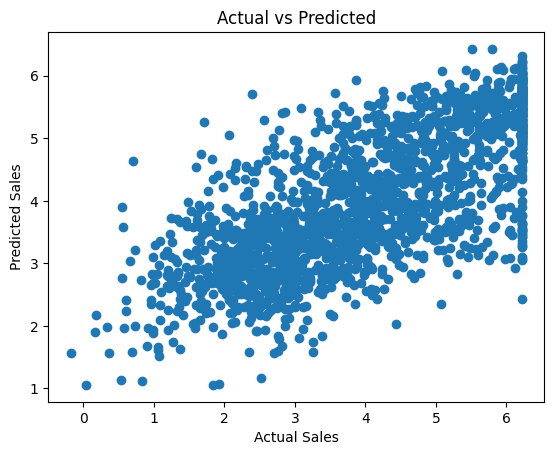

In [73]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

STEP 4: Feature Importance (VERY IMPRESSIVE)

If using Random Forest:

In [74]:
import pandas as pd

feature_names = model.named_steps['preprocess'].get_feature_names_out()
importances = model.named_steps['regressor'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(10))

                              feature  importance
667  onehot__category_Office Supplies    0.064021
81                    tfidf__shelving    0.024137
29                        tfidf__desk    0.019143
668       onehot__category_Technology    0.018471
666        onehot__category_Furniture    0.018371
34                    tfidf__electric    0.014923
92                        tfidf__wall    0.014132
40                       tfidf__frame    0.012430
63                      tfidf__outlet    0.011182
61                      tfidf__newell    0.011126
